<h1 align="center">
    THIS NOTEBOOK IS A PERSONAL REWORK OF THE Qiskit Machine Learning TUTORIAL
    <a href="https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02_neural_network_classifier_and_regressor.html">
        Neural Network Classifier & Regressor
    </a>
</h1>

_NeuralNetworkClassifier_ and _NeuralNetworkRegressor_ take as an input a (Quantum) NeuralNetwork and leverage it in a specific context. The _Variational Quantum Classifier_ (VQC) and _Variational Quantum Regressor_ (VQR) are pre-configured variants

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import qnn_circuit

from qiskit.primitives import StatevectorEstimator as Exact_Estimator
from qiskit.primitives import StatevectorSampler as Exact_Sampler

from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler

algorithm_globals.random_seed = 42

# Classification

### Prepare a binary classification dataset

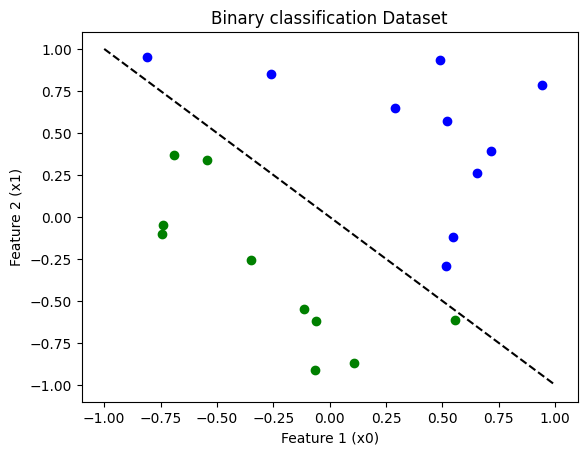

In [2]:
num_inputs = 2   # number of features
num_samples = 20   # number of datapoins
num_classes = 2   # number of classes

# Create the dataset: a (num_samples x num_inputs) table of random numbers in [-1,1]
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1

# Assign a binary label to the datapoints according to the sum of their features being > or < 0
y01 = (np.sum(X, axis = 1) >= 0) * 1  # label 1 (True = 1 * 1) if >= 0, 0 (False=0 * 1) if < 0   # label to train the Sampler classifier
y = 2 * y01 - 1  # map binary label from 0,1 to -1,1   # label to train the Estimator classifier

# Transform each class into a vector of dimension num_classes (binary: 2) with a single "1" entry: "one-hot encoding"
y_one_hot = np.zeros((num_samples, num_classes))   # label to train the Variational Quantum Classifier
for i in range(num_samples):
    y_one_hot[i, y01[i]] = 1   # y01 = 0 --> [1, 0], y01 = 1 --> [0, 1]

# Draw a feature 1 VS feature 2 plot of the datatpoints, with a binary color representing the related label value
for x, y_target in zip(X, y):   # this object has one row per datapoint. Rows look like this: [feature 1, feature 2, label]
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.xlabel("Feature 1 (x0)")
plt.ylabel("Feature 2 (x1)")
plt.title("Binary classification Dataset")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### Classification with an EstimatorQNN

Implement an _EstimatorQNN_ for classification within a _NeuralNetworkClassifier_. In this context, the EstimatorQNN must return one-dimensional outputs in [-1,+1]. This only works for binary classification: we assign the two classes to {-1,1}.

**General workflow**:
1. feature map and ansatz circuits (optional: can use default ones of qnn_circuit, see step 2)
2. quantum circuit (_qnn_circuit_)
3. Neural Network (_EstimatorQNN_)
4. Classifier (_NeuralNetworkClassifier_)

**Detailed workflow**:
1. we build the parametrized quantum circuit using _qnn_circuit_, which implement a _zz_feature_map_ feature map and a _real_amplitudes_ ansatz by default

2. we set an estimator primitive and build the associated EstimatorQNN

3. we test the QNN by running a forward pass using the first datapoint features as input, together with random weights. This is just a test anticipating the real training

4. we add a callback function called _callback_graph_ to generate a real time plot. This will be called for each iteration of the optimizer and will take two parameters: the current weights and the value of the objective (i.e., loss) function at those weights. For our callback function, we append the value of the objective function to an array so we can plot loss function values VS iterations and update the graph with each iteration.

5. we build a neural networ classifier using the following class:

    class NeuralNetworkClassifier(neural_network, loss='squared_error', one_hot=False, optimizer=None, warm_start=False, initial_point=None, callback=None)

6. train the model by fitting the classifier with the dataset X + training labels y. This step does the followying actions behind the curtains:

   6.1 Initialization: the optimizer starts with an initial guess for the weights (_anz_params_)
  
   6.2 Feature mapping and propagation: for every datapoint in the dataset ($X$), the classifier "plugs" the feature values into the input feature mapping parameters (_fm_params_) and the current weights into the _anz_params_, then  run the circuit, compute the expectation value for that datapoint, maps it to the {0,1} set, compares the resulting output with the related training label $y$, and compute the individual error

   6.3 After repeating the previous step for all datapoints, compute the loss function from the individual errors

   6.4 Call the callback function (plot loss vs current iteration)
  
   6.5 Update the optimizer, generating new weights
  
   6.6 Repeat steps 6.2-6.5 until convergence

   6.7 Save the final output weights into the estimator_classifier objcet

7. we evaluate the classifier performance with the final weights on the training labels $y$ themselves using the classifier _score_ method

8. we plot predictions to visually check their correctness

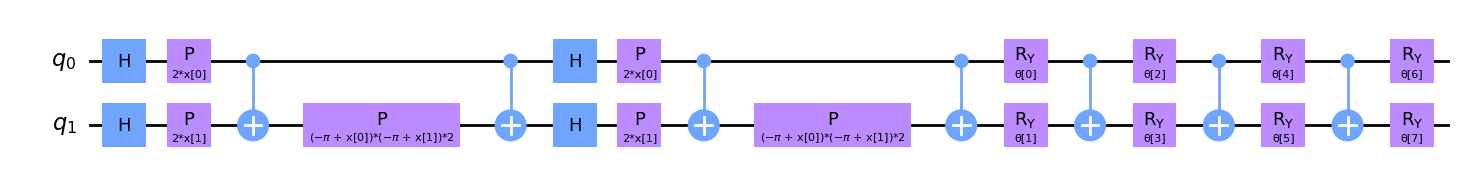

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.



2 feature map parameters: x[0] x[1]
8 ansatz parameters: θ[0] θ[1] θ[2] θ[3] θ[4] θ[5] θ[6] θ[7]
Result of the forward pass: 0.24361023814201702


In [3]:
##################################################################################################
# Construct the QNN quantum circuit. We encode one feature per qubit --> 2 qubits for features x[0], x[1]
qc, fm_params, anz_params = qnn_circuit(num_qubits = 2)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set the estimator primitive and build the EstimatorQNN. Use the default observable: Z on all qubits
estimator = Exact_Estimator()
estimator_qnn = EstimatorQNN(
    circuit = qc,
    input_params = fm_params,   # symbolic input parameters, used in building the QNN
    weight_params = anz_params,   # symbolic weight parameters, used in building the QNN
    estimator = estimator,
    pass_manager = None
)

##################################################################################################
# Run a test forward pass: the output is a 1x1 number
input_par = X[0, :]   # numeric input parameters (x[0], x[1]) taken from the dataset, used in running the forward pass
weight_par = algorithm_globals.random.random(estimator_qnn.num_weights)   # numeric weight parameters generated randomly, used in running the forward pass
estimator_qnn_forward = estimator_qnn.forward(input_par, weight_par)

##################################################################################################
# Print information
print()
print(len(fm_params), "feature map parameters:", *fm_params)
print(len(anz_params), "ansatz parameters:", *anz_params)
print(f"Result of the forward pass: {estimator_qnn_forward[0][0]}")

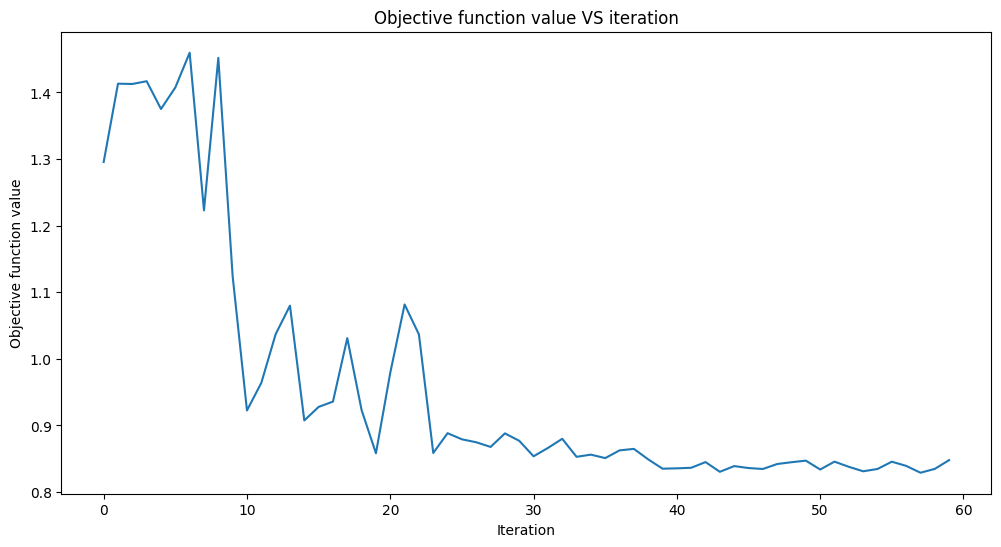

Training score: 0.6
Final weights: [ 0.74853615  0.61989515 -0.45513879 -0.49223725  1.19495252  0.19938735
  2.67691085 -0.6093949 ]



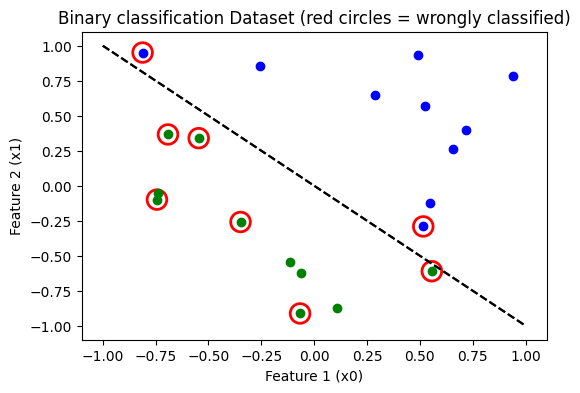

In [4]:
##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
plt.rcParams["figure.figsize"] = (12, 6)   # change the default dimensions of Matplotlib's plots

##################################################################################################
# Construct a neural network classifier: main arguments are a QNN, an optimizer, and a callback function (default loss function: squared error)
estimator_classifier = NeuralNetworkClassifier(
    neural_network = estimator_qnn,
    optimizer = COBYLA(maxiter = 60),
    callback = callback_graph
)

##################################################################################################
# Train the model: fit the classifier with the data
estimator_classifier.fit(X, y)

plt.rcParams["figure.figsize"] = (6, 4)   # return to default plot dimensions

##################################################################################################
# Evaluate the classifier performance
score = estimator_classifier.score(X, y)
final_weights = estimator_classifier.weights
print(f"Training score: {score}")
print(f"Final weights: {final_weights}\n")

##################################################################################################
# Visually check the correctness of predictions (red == wrongly classified)
y_predict = estimator_classifier.predict(X)
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s = 200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.xlabel("Feature 1 (x0)")
plt.ylabel("Feature 2 (x1)")
plt.title("Binary classification Dataset (red circles = wrongly classified)")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### Classification with a SamplerQNN

Implement a _SamplerQNN_ for classification within a _NeuralNetworkClassifier_. In this context, the SamplerQNN is expected to return $d$-dimensional probability vectors as output, where $d$ denotes the number of classes. The underlying Sampler primitive returns quasi-distributions of bit strings, so we need to define a classification mapping from the measured bitstrings to the different classes. For binary classification ($d=2$) we use the parity mapping. We employ the _StatevectorSampler_ primitive.

**General workflow**:
1. feature map and ansatz circuits (optional: can use default ones of qnn_circuit, see step 2)
2. quantum circuit (_qnn_circuit_)
3. Neural Network (_SamplerQNN_)
4. Classifier (_NeuralNetworkClassifier_)

**Detailed workflow**:
The datailed worflow is the analogous as in the EstimatorQNN scenario (but we avoid the forward pass test, this time)

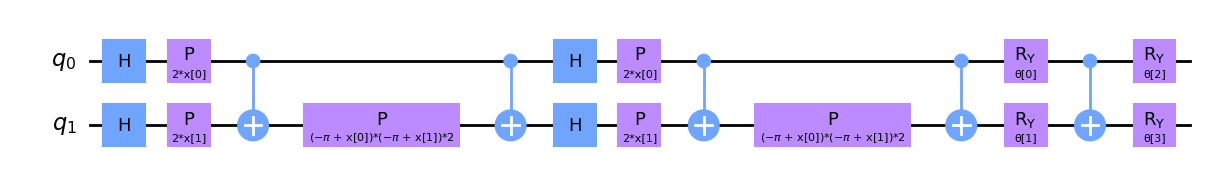

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



2 feature map parameters: x[0] x[1]
4 ansatz parameters: θ[0] θ[1] θ[2] θ[3]


In [5]:
##################################################################################################
# Construct the QNN quantum circuit, using the default zz_feature_map and a customized real_amplitudes ansatz
ansatz = real_amplitudes(num_inputs, reps = 1)
qc, fm_params, anz_params = qnn_circuit(ansatz = ansatz)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Define the parity function to map bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2
output_shape = 2  # corresponds to the number of classes, possible outcomes of the (parity) mapping

##################################################################################################
# Set the Sampler primitive and build the SamplerQNN with the parity interpret
sampler = Exact_Sampler()
sampler_qnn = SamplerQNN(
    circuit = qc,
    input_params = fm_params,   # symbolic input parameters, used in building the QNN
    weight_params = anz_params,   # symbolic weight parameters, used in building the QNN
    sampler = sampler,
    interpret = parity,
    output_shape = output_shape
)

##################################################################################################
# Print information
print()
print(len(fm_params), "feature map parameters:", *fm_params)
print(len(anz_params), "ansatz parameters:", *anz_params)

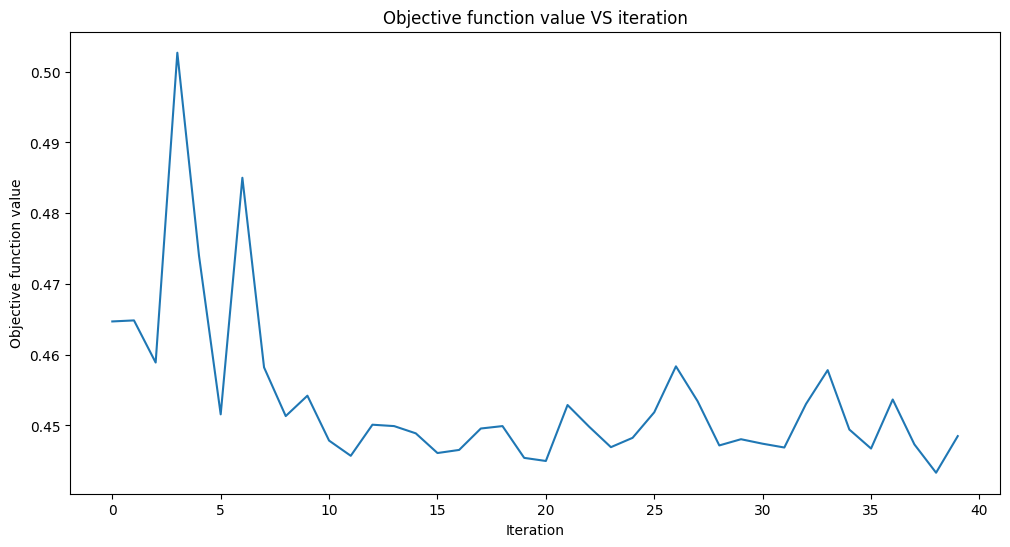

Training score: 0.65
Final weights: [ 0.31703037  1.55482838 -0.85003668 -0.24481148]



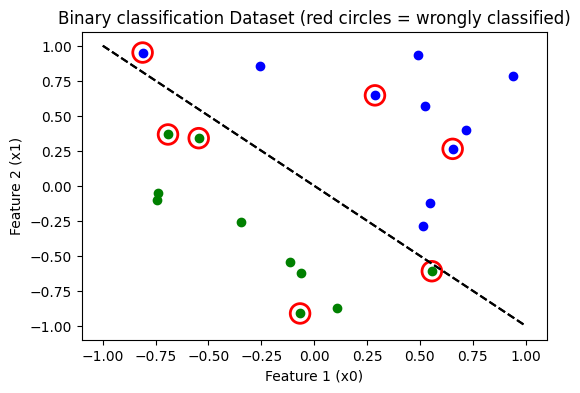

In [6]:
##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
plt.rcParams["figure.figsize"] = (12, 6)   # change the default dimensions of Matplotlib's plots

##################################################################################################
# Construct a neural network classifier: main arguments are a QNN, an optimizer, and a callback function (default loss function: squared error)
sampler_classifier = NeuralNetworkClassifier(
    neural_network = sampler_qnn,
    optimizer = COBYLA(maxiter = 40),
    callback = callback_graph
)

##################################################################################################
# Train the model : fit the classifier with the data
sampler_classifier.fit(X, y01)   # Compare with {0,1} labels, not with {-1,1} as in the EstimatorQNN scenario

plt.rcParams["figure.figsize"] = (6, 4)   # return to default plot dimensions

##################################################################################################
# Evaluate the classifier performance
score = sampler_classifier.score(X, y01)
final_weights = sampler_classifier.weights
print(f"Training score: {score}")
print(f"Final weights: {final_weights}\n")

##################################################################################################
# Visually check the correctness of predictions (red == wrongly classified)
y_predict = sampler_classifier.predict(X)
for x, y_target, y_p in zip(X, y01, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s = 200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.xlabel("Feature 1 (x0)")
plt.ylabel("Feature 2 (x1)")
plt.title("Binary classification Dataset (red circles = wrongly classified)")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### Variational Quantum Classifier (VQC) (uses Sampler primitive)

The VQC is a special variant of the _NeuralNetworkClassifier_ with a **_SamplerQNN_**. It applies a parity mapping (or extensions to multiple classes) to map from the bitstring to the classification, which results in a probability vector, which is interpreted as a one-hot encoded result. By default, it applies the _CrossEntropyLoss_ function that expects labels given in one-hot encoded format and will return predictions in that format too.

**General workflow**:
1. feature map and ansatz circuits
2. Classifier (_VQC_)

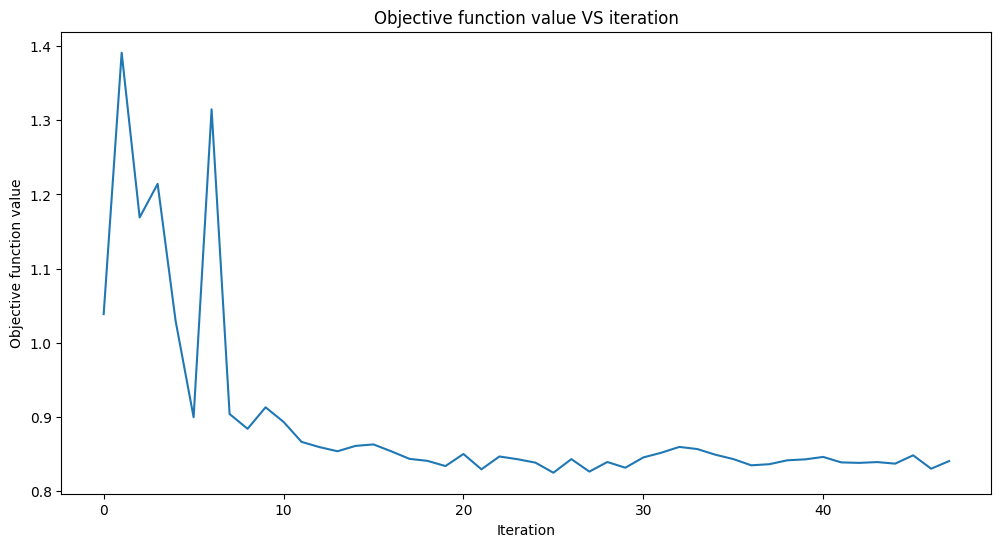

Training score: 0.75
Final weights: [-0.15752281  0.01886723  0.68918282  2.25986669]



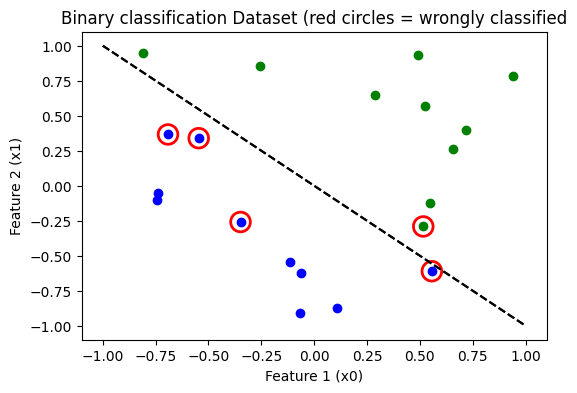

In [7]:
##################################################################################################
# Construct feature map, ansatz
feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs, reps = 1)

##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
plt.rcParams["figure.figsize"] = (12, 6)   # change the default dimensions of Matplotlib's plots

##################################################################################################
# Construct variational quantum classifier
sampler = Exact_Sampler()
vqc = VQC(
    # elements part of the neural network
    feature_map = feature_map,
    ansatz = ansatz,
    sampler = sampler,
    # elements part of the classifier
    loss = "cross_entropy",
    optimizer = COBYLA(maxiter = 60),
    callback = callback_graph,
)

##################################################################################################
# Train the model : fit the classifier with the data
vqc.fit(X, y_one_hot)   # Compare with {0,1} label: it is a Sampler classifier

plt.rcParams["figure.figsize"] = (6, 4)   # return to default plot dimensions

##################################################################################################
# Evaluate the classifier performance
score = vqc.score(X, y_one_hot)
final_weights = vqc.weights
print(f"Training score: {score}")
print(f"Final weights: {final_weights}\n")

##################################################################################################
# Visually check the correctness of predictions (red == wrongly classified)
y_predict = vqc.predict(X)
for x, y_target, y_p in zip(X, y_one_hot, y_predict):
    if y_target[0] == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if not np.all(y_target == y_p):
        plt.scatter(x[0], x[1], s = 200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.xlabel("Feature 1 (x0)")
plt.ylabel("Feature 2 (x1)")
plt.title("Binary classification Dataset (red circles = wrongly classified")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### Prepare a multi-class classification dataset

Here we generate an artificial small dataset that contains samples of three classes and show how to train a model to classify it. We employ _make_classification_ from SciKit-Learn to generate the dataset. The dataset consists of 10 samples with 2 features, and a 3-valued label (i.e., 3 classes). We set the class separation to 2.0, a slight increase from the default value of 1.0, to ease the classification problem. Once the dataset is generated, we scale the features into the range [0, 1].

We then create a VQC, but in this case we pass a minimal set of parameters: instead of a feature map and an ansatz we pass just the number of qubits (equal to the number of features in the dataset), an optimizer, a quantum instance, and a callback to observe progress --> VQC *default* feature map: *ZZFeatureMap*; VQC default ansatz: *TwoLocal*

Labels: [0 0 1 2 2 0 1 1 0 2]
Categorical labels: ['A' 'A' 'B' 'C' 'C' 'A' 'B' 'B' 'A' 'C']



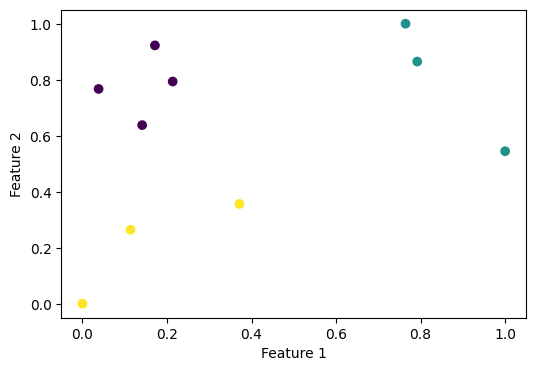

In [8]:
##################################################################################################
# Generate the dataset
X, y = make_classification(
    n_samples = 10,
    n_features = 2,
    n_classes = 3,
    n_redundant = 0,   # we want no redundant features
    n_clusters_per_class = 1,
    class_sep = 2.0,
    random_state = algorithm_globals.random_seed,
)

##################################################################################################
# Scale features in the [0,1] range
X = MinMaxScaler().fit_transform(X)

##################################################################################################
# Plot the datapoints
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.scatter(X[:, 0], X[:, 1], c = y)

##################################################################################################
# Transform labels into categorical ones
y_cat = np.empty(y.shape, dtype = str)
y_cat[y == 0] = "A"
y_cat[y == 1] = "B"
y_cat[y == 2] = "C"

##################################################################################################
# Print information
print(f"Labels: {y}")
print(f"Categorical labels: {y_cat}\n")

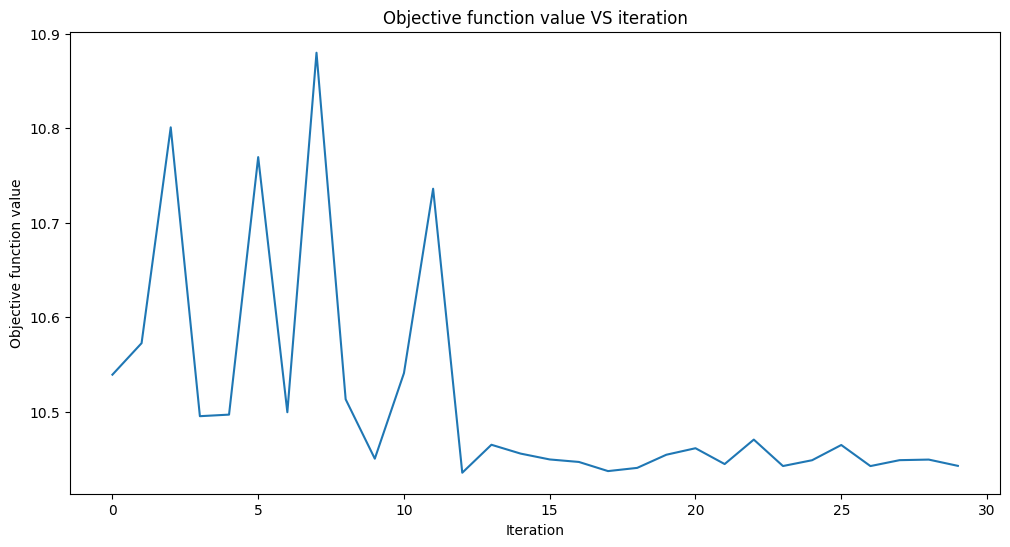

Training score: 0.5
Final weights: [ 0.52611475 -0.22331684  1.70234886  0.29855293 -0.10445303  0.4231084
 -0.63375545  0.35020046]

Predicted labels: ['B' 'A' 'B' 'A' 'A' 'B' 'B' 'B' 'B' 'B']
Ground truth:     ['A' 'A' 'B' 'C' 'C' 'A' 'B' 'B' 'A' 'C']


In [9]:
##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
plt.rcParams["figure.figsize"] = (12, 6)   # change the default dimensions of Matplotlib's plots

##################################################################################################
# Create a VQC
sampler = Exact_Sampler()
vqc = VQC(
    # elements part of the neural network
    num_qubits = 2,
    sampler = sampler,
    # elements part of the classifier
    optimizer = COBYLA(maxiter = 30),
    callback = callback_graph,
)

##################################################################################################
# Train the model : fit the classifier with the data
vqc.fit(X, y_cat)

plt.rcParams["figure.figsize"] = (6, 4)   # return to default plot dimensions

##################################################################################################
# Evaluate the classifier performance
score = vqc.score(X, y_cat)
final_weights = vqc.weights
print(f"Training score: {score}")
print(f"Final weights: {final_weights}\n")

predict = vqc.predict(X)
print(f"Predicted labels: {predict}")
print(f"Ground truth:     {y_cat}")

# Regression

### Prepare a simple regression dataset

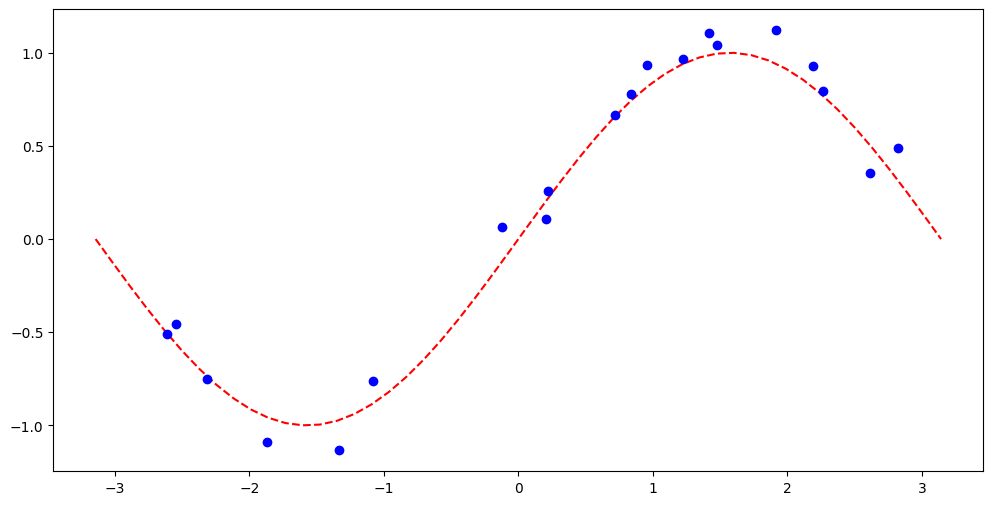

In [31]:
num_samples = 20
eps = 0.2   # epsilon: noise level to detach the real generated points from the theoretical curve
lb, ub = -np.pi, np.pi

# Theoretical data and target function: these are used to later generate the real data and target function, and for the plot
X_ = np.linspace(lb, ub, num = 50).reshape(50, 1)   # theoretical data: column array of 50 equispaced numbers in [-pi, pi]
f = lambda x: np.sin(x)   # theoretical target curve: sin function

# Real data and target function, generated from the theoretical ones. In real, practical implementations, these are the dataset elements
X = (ub - lb) * algorithm_globals.random.random([num_samples, 1]) + lb   # real data: column array of 20 random values in [-pi, pi] with uniform distribution (20 datapoints, 1 feature)
y = f(X[:, 0]) + eps * (2 * algorithm_globals.random.random(num_samples) - 1)   # real target data: obtained by adding random noise in [-eps, eps] to an exact sin function to simulate errors

plt.plot(X_, f(X_), "r--")
plt.plot(X, y, "bo")
plt.show()

### Regression with an EstimatorQNN

Here we restrict to regression with an EstimatorQNN that returns values in [-1, 1]. More complex and also multi-dimensional models could be constructed, also based on SamplerQNN but that exceeds the scope of this tutorial. We do not implement a forward pass test this time

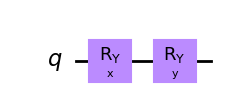

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.



1 feature map parameters: x
1 ansatz parameters: y


In [20]:
##################################################################################################
# Construct the QNN quantum circuit, with personalized feature map and ansatz. Encode one feature per qubit: 1 feature --> 1 qubit
# Feature map
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name = "fm")
feature_map.ry(param_x, 0)

# Ansatz
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name = "vf")
ansatz.ry(param_y, 0)

# Circuit
qc, fm_params, anz_params = qnn_circuit(feature_map = feature_map, ansatz = ansatz)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set the estimator primitive and build the EstimatorQNN. Use the default observable: Z on all qubits
estimator = Exact_Estimator()
regression_estimator_qnn = EstimatorQNN(
    circuit = qc,
    input_params = fm_params,   # symbolic input parameters, used in building the QNN
    weight_params = anz_params,   # symbolic weight parameters, used in building the QNN
    estimator = estimator,
    pass_manager = None
)

##################################################################################################
# Print information
print()
print(len(fm_params), "feature map parameters:", *fm_params)
print(len(anz_params), "ansatz parameters:", *anz_params)

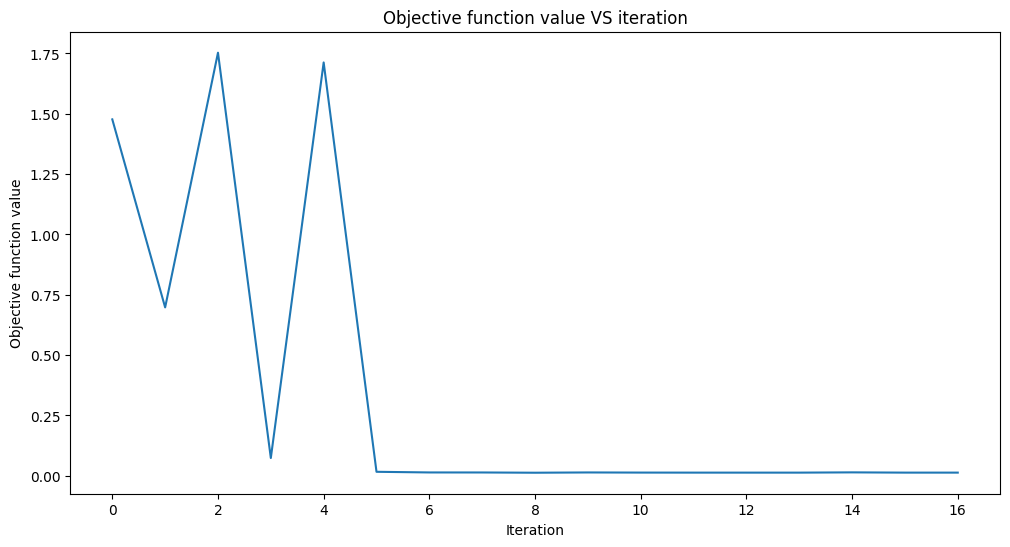

Training score: 0.9715018475096983
Final weights: [-1.55508243]



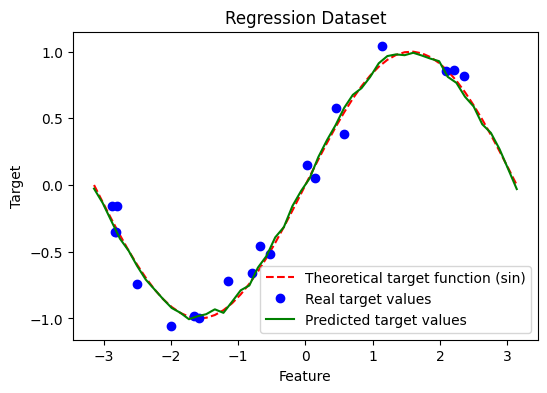

In [27]:
##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
plt.rcParams["figure.figsize"] = (12, 6)   # change the default dimensions of Matplotlib's plots

##################################################################################################
# Construct a neural network regressor: main arguments are a QNN, an optimizer, and a callback function (default loss function: squared error)
estimator_regressor = NeuralNetworkRegressor(
    neural_network = regression_estimator_qnn,
    optimizer = L_BFGS_B(maxiter = 5),
    callback = callback_graph
)

##################################################################################################
# Train the model: fit the regressor with the data
estimator_regressor.fit(X, y)

plt.rcParams["figure.figsize"] = (6, 4)   # return to default plot dimensions

##################################################################################################
# Evaluate the regressor performance
score = estimator_regressor.score(X, y)
final_weights = estimator_regressor.weights
print(f"Training score: {score}")
print(f"Final weights: {final_weights}\n")

##################################################################################################
# Visually check the correctness of predictions
y_ = estimator_regressor.predict(X_)

plt.plot(X_, f(X_), "r--", label = "Theoretical target function (sin)")   # theoretical target function vs theoretical data
plt.plot(X, y, "bo", label = "Real target values")   # real target values vs real data
plt.plot(X_, y_, "g-", label = "Predicted target values")   # predicted target values vs real data
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Regression Dataset")
plt.legend()
plt.show()

### Variational Quantum Regressor (VQR) (uses Estimator primitive)

The VQR is a special variant of the _NeuralNetworkRegressor_ with a **_EstimatorQNN_**. By default it considers the _squared_error_ loss function to minimize the mean squared error between predictions and targets

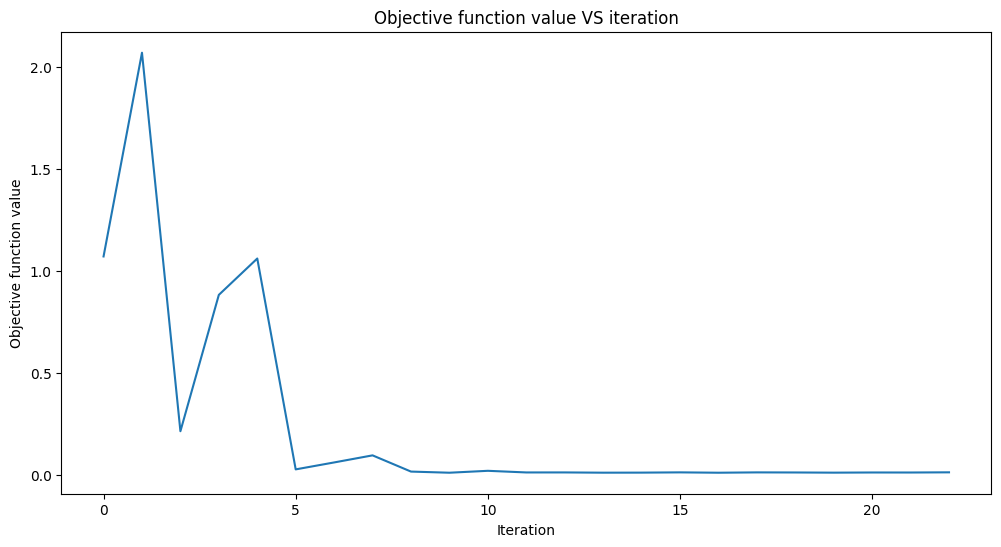

Training score: 0.9773275077430003
Final weights: [-1.58026641]



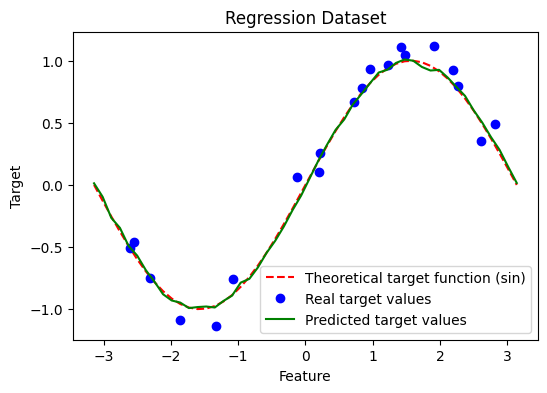

In [34]:
##################################################################################################
# Construct feature map
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name = "fm")
feature_map.ry(param_x, 0)

# Construct ansatz
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name = "vf")
ansatz.ry(param_y, 0)

##################################################################################################
# Define callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, loss_func_value):
    clear_output(wait = True)   # clear the output generated up to now. Wait for generation of new output before cleaning old one
    loss_func_array.append(loss_func_value)
    plt.title("Objective function value VS iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(loss_func_array)), loss_func_array)
    plt.show()
loss_func_array = []   # create an empty array for callback to store evaluations of the objective function
plt.rcParams["figure.figsize"] = (12, 6)   # change the default dimensions of Matplotlib's plots

##################################################################################################
# Construct variational quantum regressor
estimator = Exact_Estimator()
vqr = VQR(
    # elements part of the neural network
    feature_map = feature_map,
    ansatz = ansatz,
    estimator = estimator,
    # elements part of the classifier
    loss = "squared_error",
    optimizer = COBYLA(maxiter = 60),
    callback = callback_graph,
)

##################################################################################################
# Train the model : fit the regressor with the data
vqr.fit(X, y)

plt.rcParams["figure.figsize"] = (6, 4)   # return to default plot dimensions

##################################################################################################
# Evaluate the regressor performance
score = vqr.score(X, y)
final_weights = vqr.weights
print(f"Training score: {score}")
print(f"Final weights: {final_weights}\n")

##################################################################################################
# Visually check the correctness of predictions (red == wrongly classified)
y_ = vqr.predict(X_)

plt.plot(X_, f(X_), "r--", label = "Theoretical target function (sin)")   # theoretical target function vs theoretical data
plt.plot(X, y, "bo", label = "Real target values")   # real target values vs real data
plt.plot(X_, y_, "g-", label = "Predicted target values")   # predicted target values vs real data
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Regression Dataset")
plt.legend()
plt.show()

# Copyright

This code is a part of a Qiskit project
© Copyright IBM 2017, 2025.

This code is licensed under the Apache License, Version 2.0. You may
obtain a copy of this license in the LICENSE.txt file in the root directory
of this source tree or at http://www.apache.org/licenses/LICENSE-2.0.